# Task 1 — Exploratory Data Analysis & Preprocessing
**Project:** CrediTrust Complaint RAG Chatbot
**Goal:** Understand the structure, content, and quality of the CFPB complaint
data, then clean and filter it into the dataset that Task 2 (chunking &
embedding) will build on.

**This notebook:**
1. Loads the full CFPB complaint dataset
2. Runs an initial EDA (product distribution, narrative length, narrative
   coverage)
3. Filters to the four target products and drops empty narratives
4. Cleans the narrative text (lowercase, boilerplate removal, normalization)
5. Saves the result to `data/processed/filtered_complaints.csv`


In [3]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load the data

Update `RAW_DATA_PATH` if your file has a different name. The CFPB export is
large (464K+ rows), so we read it with `low_memory=False` to avoid dtype
guessing issues on mixed columns.

In [4]:
RAW_DATA_PATH = "../data/raw/complaints.csv"  # adjust to your actual filename

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Shape: 9,609,797 rows x 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in the complaint,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


In [5]:
# Normalize column names: lowercase, spaces/punct -> underscores.
# CFPB exports typically use headers like "Consumer complaint narrative",
# "Date received", "Product", "Company", "State", "Complaint ID".
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
print(df.columns.tolist())


['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']


In [6]:
def find_column(columns, *candidates):
    """Return the first column name that matches one of the candidate
    substrings (case-insensitive, underscore-normalized). Raises if none found
    so we fail loudly instead of silently analyzing the wrong column."""
    cols = list(columns)
    for cand in candidates:
        cand_norm = cand.lower().replace(" ", "_")
        for c in cols:
            if cand_norm in c:
                return c
    raise ValueError(f"None of {candidates} found in columns: {cols}")

COL_NARRATIVE = find_column(df.columns, "consumer_complaint_narrative", "narrative")
COL_PRODUCT   = find_column(df.columns, "product")
COL_COMPANY   = find_column(df.columns, "company")
COL_STATE     = find_column(df.columns, "state")
COL_DATE      = find_column(df.columns, "date_received")
COL_ID        = find_column(df.columns, "complaint_id")
COL_ISSUE     = find_column(df.columns, "issue")

print("narrative:", COL_NARRATIVE)
print("product  :", COL_PRODUCT)
print("company  :", COL_COMPANY)
print("state    :", COL_STATE)
print("date     :", COL_DATE)
print("id       :", COL_ID)
print("issue    :", COL_ISSUE)


narrative: consumer_complaint_narrative
product  : product
company  : company_public_response
state    : state
date     : date_received
id       : complaint_id
issue    : issue


## 2. Initial structure & quality check

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   date_received                 object
 1   product                       object
 2   sub_product                   object
 3   issue                         object
 4   sub_issue                     object
 5   consumer_complaint_narrative  object
 6   company_public_response       object
 7   company                       object
 8   state                         object
 9   zip_code                      object
 10  tags                          object
 11  consumer_consent_provided     object
 12  submitted_via                 object
 13  date_sent_to_company          object
 14  company_response_to_consumer  object
 15  timely_response               object
 16  consumer_disputed             object
 17  complaint_id                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

In [8]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].to_frame("pct_missing").round(2)


,pct_missing
tags,93.46
consumer_disputed,92.01
consumer_complaint_narrative,68.98
company_public_response,49.64
consumer_consent_provided,17.17
sub_issue,8.74
sub_product,2.45
state,0.57
zip_code,0.31
company_response_to_consumer,0.00


## 3. Exploratory Data Analysis

### 3.1 Distribution of complaints across products

product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

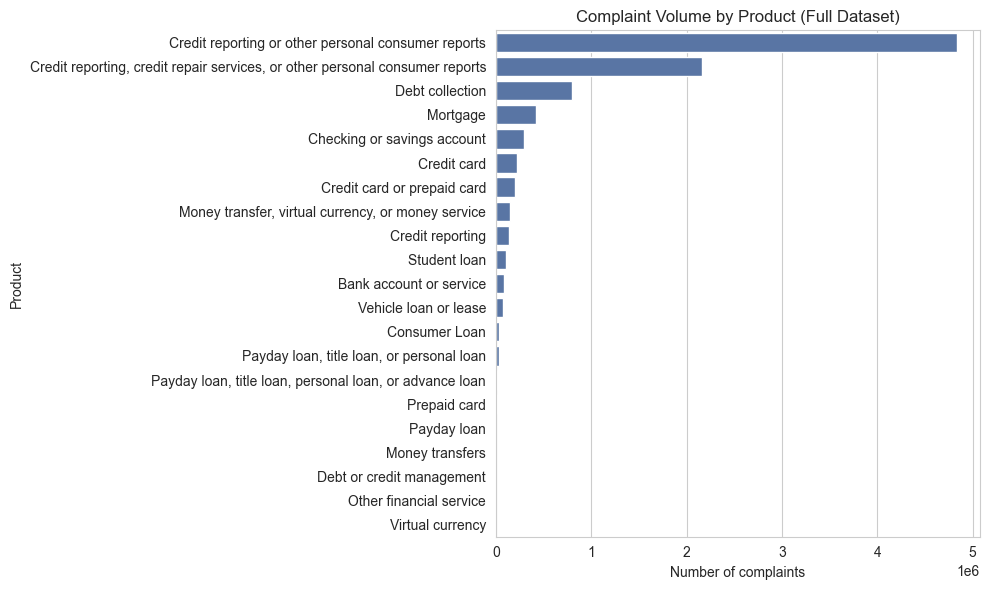

In [9]:
product_counts = df[COL_PRODUCT].value_counts()
print(product_counts)

plt.figure(figsize=(10, 6))
sns.barplot(y=product_counts.index, x=product_counts.values, color="#4C72B0")
plt.xlabel("Number of complaints")
plt.ylabel("Product")
plt.title("Complaint Volume by Product (Full Dataset)")
plt.tight_layout()
plt.show()


### 3.2 Consumer narrative length (word count)

We compute word count only for rows that actually have a narrative, then
look at the distribution, including the tails (very short and very long
entries).

In [10]:
has_narrative = df[COL_NARRATIVE].notna() & (df[COL_NARRATIVE].str.strip() != "")
df["word_count"] = df.loc[has_narrative, COL_NARRATIVE].str.split().str.len()

word_count_stats = df.loc[has_narrative, "word_count"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
word_count_stats


count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
1%       1.100000e+01
5%       2.200000e+01
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
95%      5.190000e+02
99%      1.021000e+03
max      6.469000e+03
Name: word_count, dtype: float64

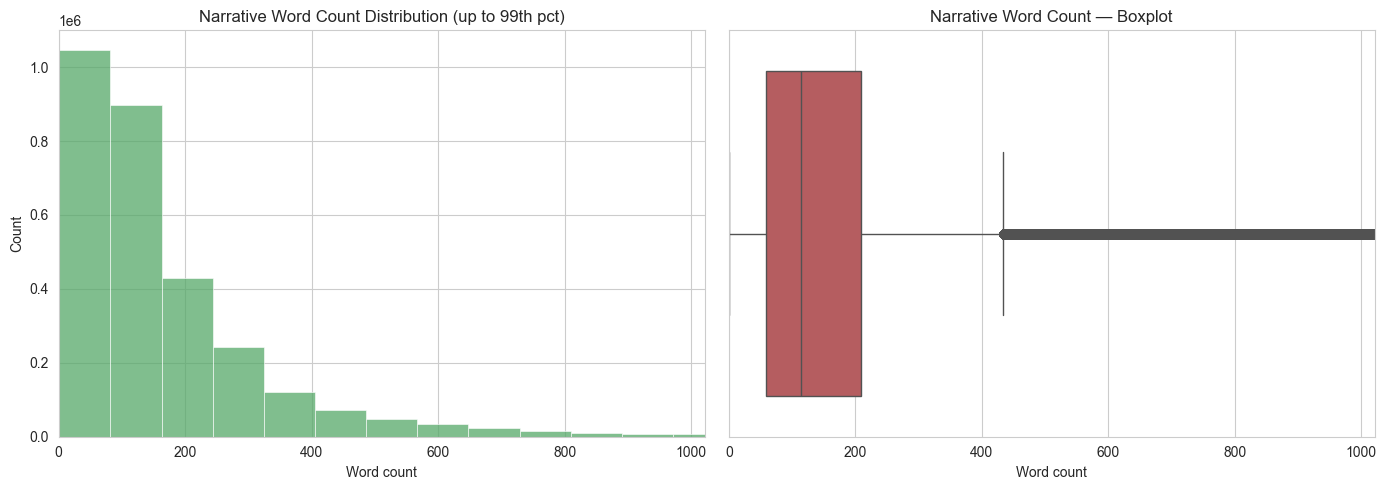

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df.loc[has_narrative, "word_count"], bins=80, ax=axes[0], color="#55A868")
axes[0].set_xlim(0, df.loc[has_narrative, "word_count"].quantile(0.99))
axes[0].set_title("Narrative Word Count Distribution (up to 99th pct)")
axes[0].set_xlabel("Word count")

sns.boxplot(x=df.loc[has_narrative, "word_count"], ax=axes[1], color="#C44E52")
axes[1].set_xlim(0, df.loc[has_narrative, "word_count"].quantile(0.99))
axes[1].set_title("Narrative Word Count — Boxplot")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()


In [12]:
SHORT_THRESHOLD = 5   # words
LONG_THRESHOLD = df.loc[has_narrative, "word_count"].quantile(0.99)

n_short = (df.loc[has_narrative, "word_count"] < SHORT_THRESHOLD).sum()
n_long = (df.loc[has_narrative, "word_count"] > LONG_THRESHOLD).sum()

print(f"Very short narratives (< {SHORT_THRESHOLD} words): {n_short:,}")
print(f"Very long narratives  (> {LONG_THRESHOLD:.0f} words, >99th pct): {n_long:,}")

print("\nExamples of very short narratives:")
display(df.loc[has_narrative & (df['word_count'] < SHORT_THRESHOLD), COL_NARRATIVE].head(5))


Very short narratives (< 5 words): 3,175
Very long narratives  (> 1021 words, >99th pct): 29,124

Examples of very short narratives:


404659    unauthorized hard inquiriesXX/XX/XXXX
530475                               XX/XX/XXXX
558331    unauthorized hard inquiriesXX/XX/XXXX
614686             XX/XX/XXXX.24\nXX/XX/XXXX.24
657271                               XX/XX/XXXX
Name: consumer_complaint_narrative, dtype: object

### 3.3 Complaints with vs. without a narrative

With narrative   : 2,980,756 (31.0%)
Without narrative: 6,629,041 (69.0%)


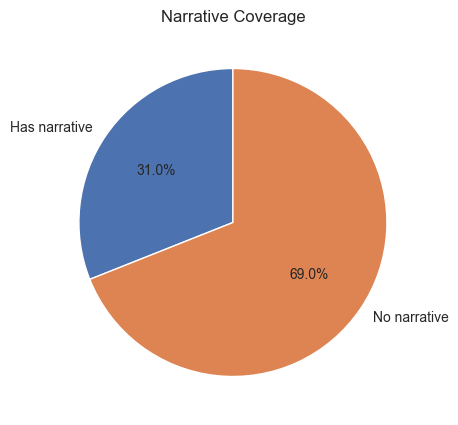

In [13]:
n_with = has_narrative.sum()
n_without = (~has_narrative).sum()
total = len(df)

print(f"With narrative   : {n_with:,} ({n_with/total:.1%})")
print(f"Without narrative: {n_without:,} ({n_without/total:.1%})")

plt.figure(figsize=(5, 5))
plt.pie(
    [n_with, n_without],
    labels=["Has narrative", "No narrative"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
)
plt.title("Narrative Coverage")
plt.show()


## 4. Filter the dataset

### 4.1 Map raw product values to the four target categories

CFPB's `Product` field uses longer, sometimes-changing label text (e.g.
*"Checking or savings account"*, *"Payday loan, title loan, or personal
loan"*). The mapping below uses keyword matching so it's robust to minor
wording differences. **Check `product_counts` above against this mapping
and adjust the keyword lists if any target category isn't being captured.**

In [14]:
PRODUCT_KEYWORDS = {
    "Credit Card": ["credit card"],
    "Personal Loan": ["payday loan", "personal loan", "title loan", "consumer loan"],
    "Savings Account": ["checking or savings account", "savings account", "bank account or service"],
    "Money Transfer": ["money transfer", "virtual currency", "money service"],
}

def map_product(raw_product):
    if pd.isna(raw_product):
        return None
    raw_lower = raw_product.lower()
    for target, keywords in PRODUCT_KEYWORDS.items():
        if any(kw in raw_lower for kw in keywords):
            return target
    return None

df["product_category"] = df[COL_PRODUCT].apply(map_product)

print("Mapped category counts:")
print(df["product_category"].value_counts())
print(f"\nUnmapped (dropped) rows: {df['product_category'].isna().sum():,}")


Mapped category counts:
product_category
Credit Card        433055
Savings Account    377383
Money Transfer     150438
Personal Loan       84270
Name: count, dtype: int64

Unmapped (dropped) rows: 8,564,651


### 4.2 Apply the filters

- Keep only rows mapped to one of the four target categories
- Drop rows with an empty/missing narrative

In [15]:
before = len(df)

filtered = df[df["product_category"].notna()].copy()
after_product_filter = len(filtered)

filtered = filtered[
    filtered[COL_NARRATIVE].notna() & (filtered[COL_NARRATIVE].str.strip() != "")
].copy()
after_narrative_filter = len(filtered)

print(f"Original rows                         : {before:,}")
print(f"After product filter (4 categories)   : {after_product_filter:,}")
print(f"After dropping empty narratives        : {after_narrative_filter:,}")
print(f"Total removed                         : {before - after_narrative_filter:,} "
      f"({(before - after_narrative_filter)/before:.1%})")


Original rows                         : 9,609,797
After product filter (4 categories)   : 1,045,146
After dropping empty narratives        : 480,580
Total removed                         : 9,129,217 (95.0%)


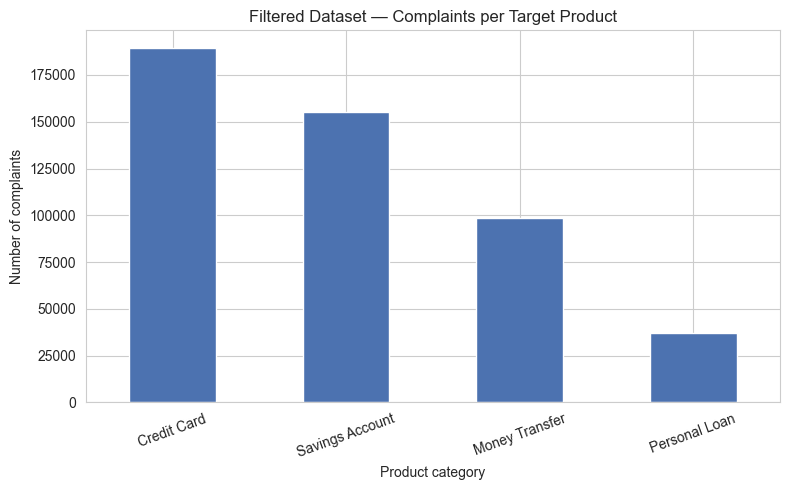

In [16]:
filtered["product_category"].value_counts().plot(
    kind="bar", color="#4C72B0", figsize=(8, 5)
)
plt.title("Filtered Dataset — Complaints per Target Product")
plt.ylabel("Number of complaints")
plt.xlabel("Product category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Clean the narrative text

Steps:
1. Lowercase
2. Remove CFPB redaction placeholders (e.g. repeated `XXXX` / `XX/XX/XXXX`
   used to mask PII)
3. Remove common boilerplate openers (e.g. *"I am writing to file a
   complaint..."*)
4. Strip special characters, punctuation noise, and excess whitespace

Adjust `BOILERPLATE_PATTERNS` as you spot more recurring filler phrases in
your data.

In [17]:
BOILERPLATE_PATTERNS = [
    r"i\s+am\s+writing\s+to\s+file\s+a\s+complaint[^.]*\.",
    r"i\s+am\s+writing\s+to\s+(?:file|lodge)\s+(?:this|a)\s+complaint[^.]*\.",
    r"this\s+is\s+(?:a\s+)?complaint\s+(?:against|regarding)[^.]*\.",
    r"to\s+whom\s+it\s+may\s+concern[,:]?",
    r"i\s+would\s+like\s+to\s+file\s+a\s+complaint[^.]*\.",
]
BOILERPLATE_RE = re.compile("|".join(BOILERPLATE_PATTERNS), flags=re.IGNORECASE)

REDACTION_RE = re.compile(r"x{2,}(?:/x{2,}){0,2}", flags=re.IGNORECASE)  # XXXX, XX/XX/XXXX
WHITESPACE_RE = re.compile(r"\s+")
SPECIAL_CHARS_RE = re.compile(r"[^a-z0-9.,!?\'\s]")


def clean_narrative(text):
    text = text.lower()
    text = BOILERPLATE_RE.sub(" ", text)
    text = REDACTION_RE.sub(" ", text)
    text = SPECIAL_CHARS_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


filtered["clean_narrative"] = filtered[COL_NARRATIVE].apply(clean_narrative)

# quick before/after sanity check
for original, cleaned in zip(
    filtered[COL_NARRATIVE].head(2), filtered["clean_narrative"].head(2)
):
    print("BEFORE:", original[:200])
    print("AFTER :", cleaned[:200])
    print("-" * 80)


BEFORE: A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unaut
AFTER : a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confir
--------------------------------------------------------------------------------
BEFORE: I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the custo
AFTER : i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their branch. i went into the branch and was told they couldn't help and had to phone the customer service
--------------------------------------------------------------------------------


In [18]:
filtered["clean_word_count"] = filtered["clean_narrative"].str.split().str.len()

# Drop rows that became empty / near-empty after cleaning (e.g. were almost
# entirely boilerplate or redacted text)
MIN_CLEAN_WORDS = 3
n_before_clean_filter = len(filtered)
filtered = filtered[filtered["clean_word_count"] >= MIN_CLEAN_WORDS].copy()
print(f"Dropped {n_before_clean_filter - len(filtered):,} rows that were "
      f"near-empty after cleaning (< {MIN_CLEAN_WORDS} words)")
print(f"Final row count: {len(filtered):,}")


Dropped 41 rows that were near-empty after cleaning (< 3 words)
Final row count: 480,539


## 6. Save the cleaned & filtered dataset

In [19]:
OUTPUT_COLUMNS = [
    COL_ID, "product_category", COL_PRODUCT, COL_ISSUE,
    COL_COMPANY, COL_STATE, COL_DATE,
    COL_NARRATIVE, "clean_narrative", "clean_word_count",
]
OUTPUT_COLUMNS = [c for c in OUTPUT_COLUMNS if c in filtered.columns]

output_path = "../data/processed/filtered_complaints.csv"
filtered[OUTPUT_COLUMNS].to_csv(output_path, index=False)
print(f"Saved {len(filtered):,} rows x {len(OUTPUT_COLUMNS)} columns to {output_path}")


Saved 480,539 rows x 10 columns to ../data/processed/filtered_complaints.csv


## 7. Summary of key EDA findings

The cell below prints a draft summary paragraph using the actual numbers
computed above — copy it into your report and edit the wording/emphasis as
needed.

In [20]:
top_product = product_counts.idxmax()
pct_with_narrative = n_with / total

summary = f'''
The full CFPB dataset contains {total:,} complaints spanning {df[COL_PRODUCT].nunique()} \
raw product categories. {top_product} is the single most-reported product, with \
{product_counts.max():,} complaints ({product_counts.max()/total:.1%} of the total). \
Only {pct_with_narrative:.1%} of complaints ({n_with:,} of {total:,}) include a free-text \
consumer narrative; the remaining {n_without:,} were excluded from downstream analysis since \
the RAG pipeline depends on narrative text.

Among complaints with a narrative, word count is highly right-skewed: the median narrative is \
{word_count_stats["50%"]:.0f} words, but the 99th percentile reaches {LONG_THRESHOLD:.0f} words, \
and {n_short:,} narratives are extremely short (under {SHORT_THRESHOLD} words) and carry little \
analytical signal. After filtering to the four target products (Credit Card, Personal Loan, \
Savings Account, Money Transfer) and removing empty/near-empty narratives, the cleaned dataset \
retains {len(filtered):,} complaints ({len(filtered)/before:.1%} of the original), saved to \
data/processed/filtered_complaints.csv for use in Task 2.
'''

print(summary)



The full CFPB dataset contains 9,609,797 complaints spanning 21 raw product categories. Credit reporting or other personal consumer reports is the single most-reported product, with 4,834,855 complaints (50.3% of the total). Only 31.0% of complaints (2,980,756 of 9,609,797) include a free-text consumer narrative; the remaining 6,629,041 were excluded from downstream analysis since the RAG pipeline depends on narrative text.

Among complaints with a narrative, word count is highly right-skewed: the median narrative is 114 words, but the 99th percentile reaches 1021 words, and 3,175 narratives are extremely short (under 5 words) and carry little analytical signal. After filtering to the four target products (Credit Card, Personal Loan, Savings Account, Money Transfer) and removing empty/near-empty narratives, the cleaned dataset retains 480,539 complaints (5.0% of the original), saved to data/processed/filtered_complaints.csv for use in Task 2.

